In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print("All imports successful!")

All imports successful!


In [5]:
df = pd.read_csv('../data/raw/complaints.csv', 
                 low_memory=False, 
                 nrows=50000)  # only load first 50K rows

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (50000, 18)

Columns: ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']


In [6]:
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date received                 50000 non-null  str    
 1   Product                       50000 non-null  str    
 2   Sub-product                   50000 non-null  str    
 3   Issue                         50000 non-null  str    
 4   Sub-issue                     49572 non-null  str    
 5   Consumer complaint narrative  672 non-null    str    
 6   Company public response       1342 non-null   str    
 7   Company                       50000 non-null  str    
 8   State                         49945 non-null  str    
 9   ZIP code                      50000 non-null  str    
 10  Tags                          1030 non-null   str    
 11  Consumer consent provided?    1649 non-null   str    
 12  Submitted via                 50000 non-null  str    
 13  Date sent to

In [9]:
chunks = []
total_rows = 0
target = 15000  # we only need 15K rows

for chunk in pd.read_csv('../data/raw/complaints.csv', 
                          low_memory=False, 
                          chunksize=50000,
                          on_bad_lines='skip'):  # skip corrupted lines
    
    filtered = chunk[chunk['Consumer complaint narrative'].notna()]
    chunks.append(filtered)
    total_rows += len(filtered)
    print(f"Loaded chunk, kept {len(filtered)} rows | Total so far: {total_rows}")
    
    # Stop once we have enough
    if total_rows >= target:
        print("Got enough rows, stopping!")
        break

df = pd.concat(chunks, ignore_index=True)

# Trim to exactly 15K
df = df.head(15000)

print(f"\nFinal shape: {df.shape}")

Loaded chunk, kept 672 rows | Total so far: 672
Loaded chunk, kept 1142 rows | Total so far: 1814
Loaded chunk, kept 1453 rows | Total so far: 3267
Loaded chunk, kept 1484 rows | Total so far: 4751
Loaded chunk, kept 1020 rows | Total so far: 5771
Loaded chunk, kept 2393 rows | Total so far: 8164
Loaded chunk, kept 3676 rows | Total so far: 11840
Loaded chunk, kept 3334 rows | Total so far: 15174
Got enough rows, stopping!

Final shape: (15000, 18)


In [10]:
print("Product distribution:")
print(df['Product'].value_counts())

Product distribution:
Product
Credit reporting or other personal consumer reports                             10547
Debt collection                                                                  1549
Checking or savings account                                                       911
Credit card                                                                       893
Mortgage                                                                          350
Money transfer, virtual currency, or money service                                200
Vehicle loan or lease                                                             194
Student loan                                                                      137
Payday loan, title loan, personal loan, or advance loan                           123
Prepaid card                                                                       44
Debt or credit management                                                          37
Credit reporting, credit

In [11]:
# Define which product names map to our 4 categories
product_mapping = {
    'Credit card': 'Credit Card',
    'Credit card or prepaid card': 'Credit Card',
    'Payday loan, title loan, personal loan, or advance loan': 'Personal Loan',
    'Checking or savings account': 'Savings Account',
    'Money transfer, virtual currency, or money service': 'Money Transfer'
}

# Filter to only rows where Product is in our mapping
df_filtered = df[df['Product'].isin(product_mapping.keys())].copy()

# Add a clean category column
df_filtered['product_category'] = df_filtered['Product'].map(product_mapping)

print("Shape after filtering:", df_filtered.shape)
print("\nNew category distribution:")
print(df_filtered['product_category'].value_counts())

Shape after filtering: (2129, 19)

New category distribution:
product_category
Savings Account    911
Credit Card        895
Money Transfer     200
Personal Loan      123
Name: count, dtype: int64


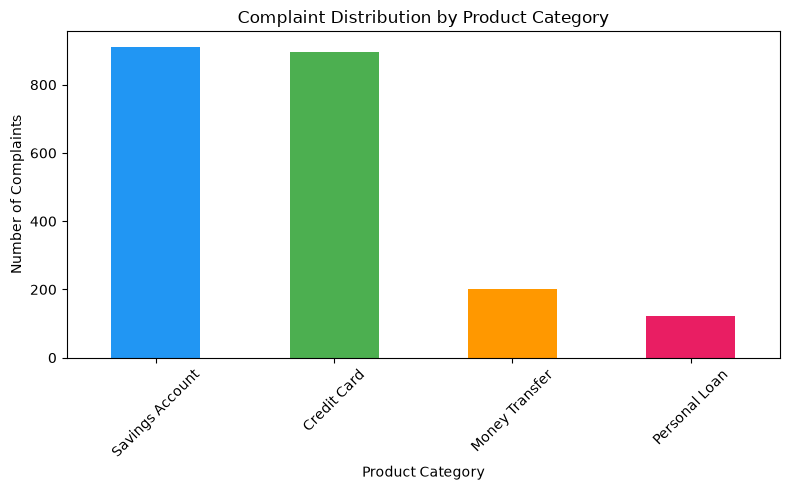

Plot saved!


In [12]:
plt.figure(figsize=(8, 5))
df_filtered['product_category'].value_counts().plot(kind='bar', color=['#2196F3', '#4CAF50', '#FF9800', '#E91E63'])
plt.title('Complaint Distribution by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/processed/complaint_distribution.png')
plt.show()
print("Plot saved!")

Narrative length stats:
count    2129.000000
mean      220.603100
std       201.121201
min         9.000000
25%        99.000000
50%       176.000000
75%       286.000000
max      3456.000000
Name: narrative_word_count, dtype: float64


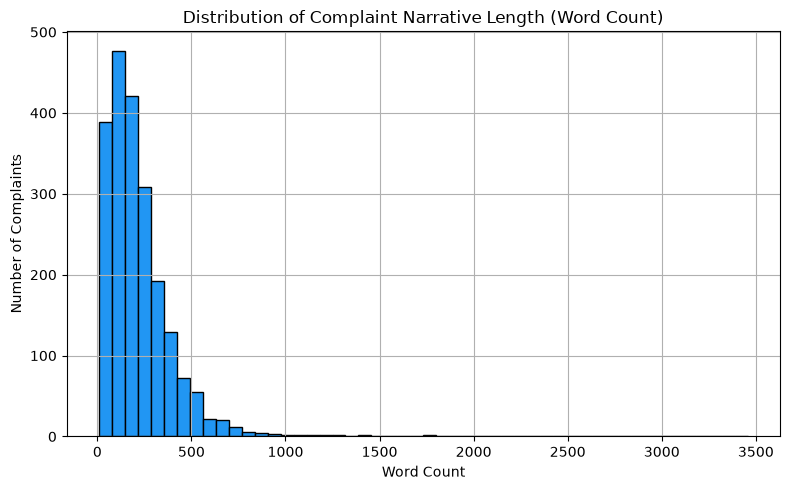

In [13]:
# Calculate word count for each narrative
df_filtered['narrative_word_count'] = df_filtered['Consumer complaint narrative'].apply(lambda x: len(str(x).split()))

print("Narrative length stats:")
print(df_filtered['narrative_word_count'].describe())

plt.figure(figsize=(8, 5))
df_filtered['narrative_word_count'].hist(bins=50, color='#2196F3', edgecolor='black')
plt.title('Distribution of Complaint Narrative Length (Word Count)')
plt.xlabel('Word Count')
plt.ylabel('Number of Complaints')
plt.tight_layout()
plt.savefig('../data/processed/narrative_length_distribution.png')
plt.show()

In [14]:
# Cell — look at a raw narrative
print(df_filtered['Consumer complaint narrative'].iloc[0])

A XXXX XXXX card was opened under my name by a fraudster. I received a notice from XXXX  that an account was just opened under my name. I reached out to XXXX XXXX to state that this activity was unauthorized and not me. XXXX XXXX confirmed this was fraudulent and immediately closed the card. However, they have failed to remove this from the three credit agencies and this fraud is now impacting my credit score based on a hard credit pull done by XXXX XXXX that was done by a fraudster.


In [15]:
import re

def clean_narrative(text):
    # 1. Lowercase
    text = text.lower()
    
    # 2. Remove XXXX placeholders (privacy redactions)
    text = re.sub(r'x{2,}', '', text)
    
    # 3. Remove common boilerplate phrases
    boilerplate = [
        'i am writing to file a complaint',
        'i am writing to dispute',
        'to whom it may concern',
        'i am writing because',
    ]
    for phrase in boilerplate:
        text = text.replace(phrase, '')
    
    # 4. Remove special characters but keep punctuation
    text = re.sub(r'[^a-zA-Z0-9\s\.\,\!\?\-]', '', text)
    
    # 5. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply to our dataframe
df_filtered['cleaned_narrative'] = df_filtered['Consumer complaint narrative'].apply(clean_narrative)

print("Original:")
print(df_filtered['Consumer complaint narrative'].iloc[0])
print("\nCleaned:")
print(df_filtered['cleaned_narrative'].iloc[0])

Original:
A XXXX XXXX card was opened under my name by a fraudster. I received a notice from XXXX  that an account was just opened under my name. I reached out to XXXX XXXX to state that this activity was unauthorized and not me. XXXX XXXX confirmed this was fraudulent and immediately closed the card. However, they have failed to remove this from the three credit agencies and this fraud is now impacting my credit score based on a hard credit pull done by XXXX XXXX that was done by a fraudster.

Cleaned:
a card was opened under my name by a fraudster. i received a notice from that an account was just opened under my name. i reached out to to state that this activity was unauthorized and not me. confirmed this was fraudulent and immediately closed the card. however, they have failed to remove this from the three credit agencies and this fraud is now impacting my credit score based on a hard credit pull done by that was done by a fraudster.


In [16]:
# Check word count after cleaning
df_filtered['cleaned_word_count'] = df_filtered['cleaned_narrative'].apply(lambda x: len(x.split()))

print("Word count stats after cleaning:")
print(df_filtered['cleaned_word_count'].describe())

# Remove narratives that are too short to be useful (less than 20 words)
df_clean = df_filtered[df_filtered['cleaned_word_count'] >= 20].copy()

print(f"\nBefore removing short narratives: {len(df_filtered)}")
print(f"After removing short narratives: {len(df_clean)}")

Word count stats after cleaning:
count    2129.000000
mean      208.000000
std       185.059973
min         0.000000
25%        94.000000
50%       167.000000
75%       270.000000
max      3356.000000
Name: cleaned_word_count, dtype: float64

Before removing short narratives: 2129
After removing short narratives: 2092


In [17]:
df_clean = df_clean[[
    'Complaint ID',
    'product_category',
    'Product',
    'Issue',
    'Sub-issue',
    'Company',
    'State',
    'Date received',
    'cleaned_narrative'
]].copy()

# Rename columns to be cleaner
df_clean.columns = [
    'complaint_id',
    'product_category', 
    'product',
    'issue',
    'sub_issue',
    'company',
    'state',
    'date_received',
    'cleaned_narrative'
]

print("Final shape:", df_clean.shape)
print("\nSample row:")
print(df_clean.iloc[0])

Final shape: (2092, 9)

Sample row:
complaint_id                                                  14069121
product_category                                           Credit Card
product                                                    Credit card
issue                                            Getting a credit card
sub_issue                  Card opened without my consent or knowledge
company                                                 CITIBANK, N.A.
state                                                               TX
date_received                                               2025-06-13
cleaned_narrative    a card was opened under my name by a fraudster...
Name: 4, dtype: object


In [ ]:
# Save to processed folder
df_clean.to_csv('../data/processed/filtered_complaints.csv', index=False)

print("Saved successfully!")
print(f"Final dataset: {df_clean.shape[0]} complaints across {df_clean['product_category'].nunique()} product categories")
print("\nFinal distribution:")
print(df_clean['product_category'].value_counts())

Saved successfully!
Final dataset: 2092 complaints across 4 product categories

Final distribution:
product_category
Savings Account    896
Credit Card        874
Money Transfer     200
Personal Loan      122
Name: count, dtype: int64


: 